# Chapter 10. 회귀불연속설계 (Regression Discontinuity Design)

## 학습 목표

- 회귀불연속설계(RDD)의 기본 직관과 가정을 이해한다
- Sharp RDD와 Fuzzy RDD의 차이를 학습한다
- 국소 선형 회귀(Local Linear Regression)로 처치 효과를 추정한다
- 최적 대역폭(Optimal Bandwidth) 선택 방법을 학습한다
- 실제 데이터(음주 가능 연령 임계값)에서 RDD를 적용한다
- McCrary 밀도 검정으로 조작을 탐지한다
- OpenAI SDK를 통해 배정변수와 임계값을 자동 탐지한다

In [21]:
# ============================================================
# 필수 패키지 설치 및 import
# ============================================================
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize_scalar
import statsmodels.api as sm
from statsmodels.formula.api import ols
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Optional, Dict, Any

# 환경 변수 로드 및 OpenAI 클라이언트 초기화
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

print("✓ 모든 패키지 import 완료")

✓ 모든 패키지 import 완료


## 1. RDD의 직관: 임계값에서의 불연속

**회귀불연속설계(RDD)**는 배정변수(Running Variable)가 임계값(Cutoff)을 넘을 때 처치 배정이 불연속적으로 변하는 상황을 이용한다.

예시:
- **음주 가능 연령**: 나이 21세 이상이면 음주 가능 (Sharp RDD)
- **대학 입시**: 입시 점수 임계값 이상이면 입학 (Fuzzy RDD)

핵심 아이디어:
- 임계값 바로 아래와 위의 개인들은 모든 특성에서 거의 동일하다
- 유일한 차이는 처치 배정뿐이다
- 따라서 결과변수의 불연속 점프가 순수 처치 효과다

$$\tau_{RDD} = \lim_{x \downarrow c} E[Y|X=x] - \lim_{x \uparrow c} E[Y|X=x]$$

In [22]:
# ============================================================
# RDD 시뮬레이션: 임계값에서의 불연속 점프
# ============================================================
# 배정변수 X ~ Uniform(0, 100), 임계값 c=50
# X >= 50이면 처치를 받는다
# 진정한 처치 효과 τ = 5

np.random.seed(42)

n = 1000
cutoff = 50
true_effect = 5

# 배정변수 생성
X = np.random.uniform(0, 100, n)

# 처치 배정 (Sharp RDD)
D = (X >= cutoff).astype(int)

# 결과변수: Y = α + τ·D + β₁·(X - c) + β₂·D·(X - c) + ε
# α=20 (절편), β₁=0.5 (아래쪽 기울기), β₂=0.3 (기울기 변화)
alpha = 20
beta1 = 0.5
beta2 = 0.3
epsilon = np.random.normal(0, 3, n)  # 노이즈

Y = alpha + true_effect * D + beta1 * (X - cutoff) + beta2 * D * (X - cutoff) + epsilon

print(f"데이터 생성 완료")
print(f"표본 크기: {n}")
print(f"임계값: {cutoff}")
print(f"처치 받은 개수: {D.sum()}")
print(f"진정한 처치 효과: {true_effect}")


데이터 생성 완료
표본 크기: 1000
임계값: 50
처치 받은 개수: 497
진정한 처치 효과: 5


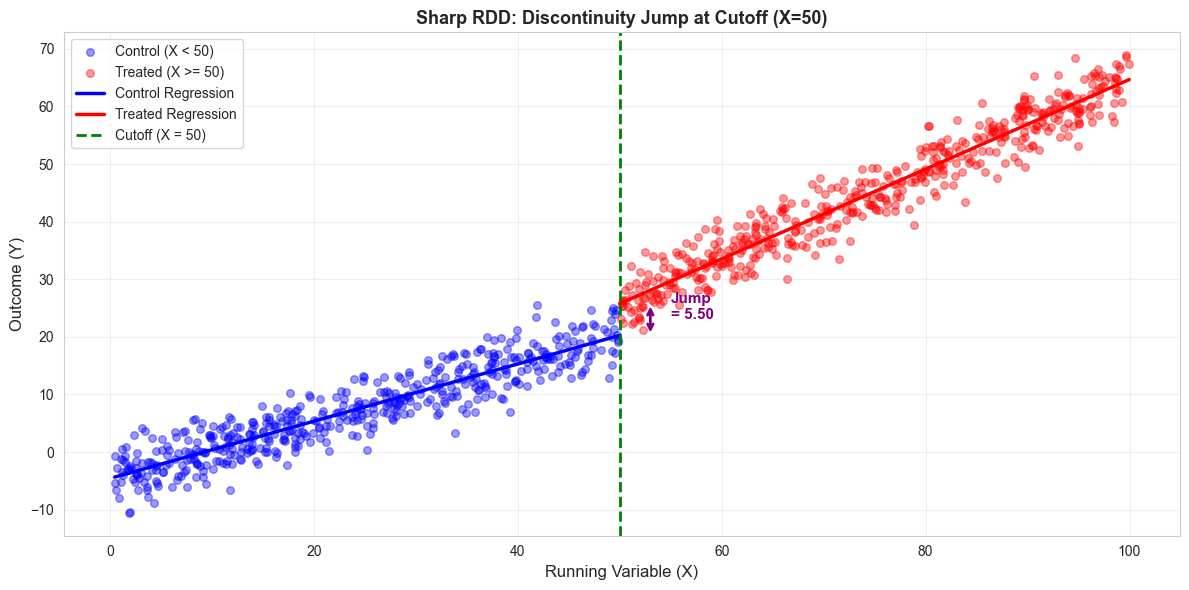

Mean left of cutoff: 7.26
Mean right of cutoff: 44.87
Jump size: 37.61 (true effect: 5)


In [23]:
# ============================================================
# RDD Visualization: Scatter plot and regression lines around cutoff
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Split into control and treatment groups
mask_control = X < cutoff
mask_treated = X >= cutoff

# Scatter
ax.scatter(X[mask_control], Y[mask_control], alpha=0.4, s=30, label='Control (X < 50)', color='blue')
ax.scatter(X[mask_treated], Y[mask_treated], alpha=0.4, s=30, label='Treated (X >= 50)', color='red')

# Linear regression lines on each side
# Control
X_control = X[mask_control]
Y_control = Y[mask_control]
z_control = np.polyfit(X_control, Y_control, 1)
p_control = np.poly1d(z_control)
x_line_control = np.linspace(X_control.min(), cutoff, 50)
ax.plot(x_line_control, p_control(x_line_control), 'b-', linewidth=2.5, label='Control Regression')

# Treated
X_treated = X[mask_treated]
Y_treated = Y[mask_treated]
z_treated = np.polyfit(X_treated, Y_treated, 1)
p_treated = np.poly1d(z_treated)
x_line_treated = np.linspace(cutoff, X_treated.max(), 50)
ax.plot(x_line_treated, p_treated(x_line_treated), 'r-', linewidth=2.5, label='Treated Regression')

# Cutoff line
ax.axvline(cutoff, color='green', linestyle='--', linewidth=2, label=f'Cutoff (X = {cutoff})')

# Discontinuity jump arrow
y_left = p_control(cutoff)
y_right = p_treated(cutoff)
ax.annotate('', xy=(cutoff + 3, y_right), xytext=(cutoff + 3, y_left),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(cutoff + 5, (y_left + y_right) / 2, f'Jump\n= {y_right - y_left:.2f}',
        fontsize=11, color='purple', weight='bold')

ax.set_xlabel('Running Variable (X)', fontsize=12)
ax.set_ylabel('Outcome (Y)', fontsize=12)
ax.set_title('Sharp RDD: Discontinuity Jump at Cutoff (X=50)', fontsize=13, weight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean left of cutoff: {Y_control.mean():.2f}')
print(f'Mean right of cutoff: {Y_treated.mean():.2f}')
print(f'Jump size: {Y_treated.mean() - Y_control.mean():.2f} (true effect: {true_effect})')


## 2. Sharp RDD 수동 구현

**Sharp RDD 회귀식:**

$$Y_i = \alpha + \tau \cdot \mathbf{1}(X_i \geq c) + \beta_1(X_i - c) + \beta_2 \cdot \mathbf{1}(X_i \geq c) \cdot (X_i - c) + \varepsilon_i$$

여기서:
- $\tau$: 처치 효과 (임계값에서의 불연속 점프)
- $(X_i - c)$: 중심화된 배정변수 (Running variable centered at cutoff)
- $\mathbf{1}(X_i \geq c)$: 처치 더미변수
- $\beta_2$ 상호작용항: 처치 양쪽의 기울기 차이 허용

In [24]:
# ============================================================
# Sharp RDD: OLS 추정 (수동 구현)
# ============================================================

def estimate_sharp_rdd(X, Y, cutoff, formula=None):
    """
    Sharp RDD를 OLS로 추정한다.
    """
    # 데이터프레임 생성
    df = pd.DataFrame({
        'Y': Y,
        'X': X,
        'above_cutoff': (X >= cutoff).astype(int),
        'X_centered': X - cutoff
    })
    
    # 상호작용항 생성
    df['X_X_above'] = df['X_centered'] * df['above_cutoff']
    
    # 기본 공식
    if formula is None:
        model = ols('Y ~ above_cutoff + X_centered + X_X_above', data=df)
    else:
        model = ols(formula, data=df)
    
    # HC1 강건한 표준오차로 추정
    result = model.fit(cov_type='HC1')
    
    return result, df

# RDD 추정 실행
result, df_rdd = estimate_sharp_rdd(X, Y, cutoff)

# 결과 출력
print("="*60)
print("Sharp RDD 추정 결과")
print("="*60)
print(result.summary())
print()
print(f"추정된 처치 효과: {result.params['above_cutoff']:.4f}")
print(f"표준오차: {result.bse['above_cutoff']:.4f}")
print(f"t-통계량: {result.tvalues['above_cutoff']:.4f}")
print(f"p-값: {result.pvalues['above_cutoff']:.4f}")


Sharp RDD 추정 결과
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 1.684e+04
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:50:44   Log-Likelihood:                -2502.9
No. Observations:                1000   AIC:                             5014.
Df Residuals:                     996   BIC:                             5033.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       20.2663      0.2

## 3. 대역폭(Bandwidth) 선택과 민감도 분석

RDD의 핵심 가정은 "임계값 근처의 개인들은 모든 특성에서 동일하다"는 것이다.

**대역폭 선택의 트레이드오프:**
- **좁은 대역폭**: 가정이 더 타당하지만, 표본이 작아져 분산이 크다
- **넓은 대역폭**: 표본이 많아 분산이 작지만, 가정이 위배될 수 있다

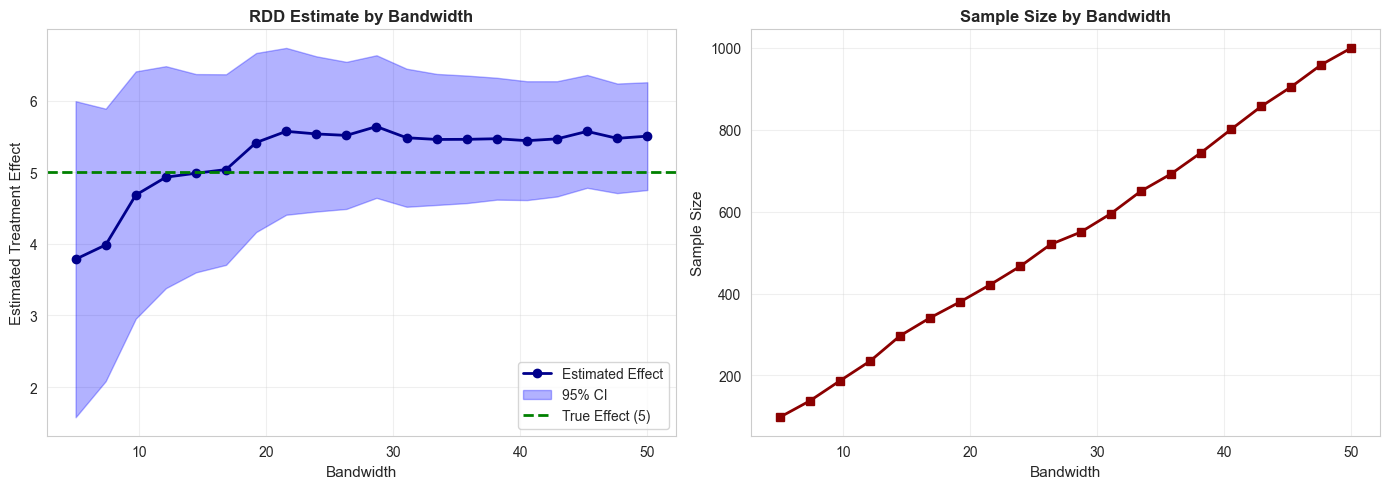

In [25]:
# ============================================================
# Bandwidth Sensitivity Analysis
# ============================================================

def rdd_with_bandwidth(X, Y, cutoff, bandwidth):
    """
    Estimate RDD with a given bandwidth.
    """
    mask = np.abs(X - cutoff) <= bandwidth
    X_bw = X[mask]
    Y_bw = Y[mask]
    result, _ = estimate_sharp_rdd(X_bw, Y_bw, cutoff)
    return result, len(X_bw)

# Estimate across various bandwidths
bandwidths = np.linspace(5, 50, 20)
estimates = []
ses = []
sample_sizes = []

for bw in bandwidths:
    result, n_bw = rdd_with_bandwidth(X, Y, cutoff, bw)
    estimates.append(result.params['above_cutoff'])
    ses.append(result.bse['above_cutoff'])
    sample_sizes.append(n_bw)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
estimates_arr = np.array(estimates)
ses_arr = np.array(ses)
ci_lower = estimates_arr - 1.96 * ses_arr
ci_upper = estimates_arr + 1.96 * ses_arr

ax1.plot(bandwidths, estimates_arr, 'o-', color='darkblue', linewidth=2, label='Estimated Effect')
ax1.fill_between(bandwidths, ci_lower, ci_upper, alpha=0.3, color='blue', label='95% CI')
ax1.axhline(true_effect, color='green', linestyle='--', linewidth=2, label=f'True Effect ({true_effect})')
ax1.set_xlabel('Bandwidth', fontsize=11)
ax1.set_ylabel('Estimated Treatment Effect', fontsize=11)
ax1.set_title('RDD Estimate by Bandwidth', fontsize=12, weight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(bandwidths, sample_sizes, 's-', color='darkred', linewidth=2)
ax2.set_xlabel('Bandwidth', fontsize=11)
ax2.set_ylabel('Sample Size', fontsize=11)
ax2.set_title('Sample Size by Bandwidth', fontsize=12, weight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. LLM 기반 배정변수/임계값 자동 탐지

구조화된 출력(Structured Outputs)을 이용하여 데이터셋의 컨텍스트에서 배정변수와 임계값을 자동으로 식별한다.

In [26]:
# ============================================================
# Pydantic 구조화된 출력 모델 정의
# ============================================================

class RDDVariables(BaseModel):
    """
    RDD 분석에 필요한 배정변수와 임계값을 식별하는 모델
    """
    running_variable: str = Field(..., description="배정변수(Running Variable) 칼럼명")
    cutoff_value: float = Field(..., description="임계값(Cutoff) 수치")
    outcome_variable: str = Field(..., description="결과변수(Outcome) 칼럼명")
    rdd_type: str = Field(..., description="RDD 유형: 'sharp' 또는 'fuzzy'")
    interpretation: str = Field(..., description="이 RDD 임계값의 실제 의미")

# 테스트: 합성 데이터셋 설명으로 LLM 호출
context = """
데이터셋: 1000명의 미국 성인
칼럼:
- age: 나이 (18~65세)
- alcohol_consumption: 월간 음주량 (리터)
- health_status: 건강 상태 점수 (0~100)
- income: 연간 소득 (달러)

배경: 미국에서는 21세부터 술을 구매할 수 있다.
우리는 음주 가능 나이가 건강과 소비에 미치는 영향을 분석하려고 한다.
"""

response = client.chat.completions.parse(
    model="gpt-4o",
    max_tokens=1024,
    messages=[{
        "role": "user",
        "content": f"다음 데이터셋에서 RDD 분석에 필요한 배정변수, 임계값, 결과변수를 식별하세요:\n\n{context}"
    }],
    response_format=RDDVariables,
)

identified_vars = response.choices[0].message.parsed

print("="*60)
print("LLM이 자동으로 식별한 RDD 변수")
print("="*60)
print(f"배정변수: {identified_vars.running_variable}")
print(f"임계값: {identified_vars.cutoff_value}")
print(f"결과변수: {identified_vars.outcome_variable}")
print(f"RDD 유형: {identified_vars.rdd_type}")

LLM이 자동으로 식별한 RDD 변수
배정변수: age
임계값: 21.0
결과변수: health_status
RDD 유형: sharp


## 5. 실제 데이터 분석: drinking.csv

**데이터**: Carpenter & Dobkin (2011) - 음주 가능 나이의 사망률 영향

**배경**: 미국에서 법적 음주 가능 나이(MLDA)는 21세다.

In [28]:
# ============================================================
# 데이터 로드 및 탐색적 분석
# ============================================================

data_path = "./dataset/drinking.csv"

df_drinking = pd.read_csv(data_path)

print("데이터 로드 완료")
print(f"표본 크기: {len(df_drinking)}")
print(f"\n칼럼명:")
print(df_drinking.columns.tolist())
print(f"\n데이터 요약:")
print(df_drinking.head(10))
print(f"\n기초통계:")
print(df_drinking.describe())


데이터 로드 완료
표본 크기: 50

칼럼명:
['agecell', 'all', 'internal', 'external', 'alcohol', 'homicide', 'suicide', 'mva', 'drugs', 'externalother']

데이터 요약:
     agecell        all   internal   external   alcohol   homicide    suicide  \
0  19.068493  92.825400  16.617590  76.207820  0.639138  16.316818  11.203714   
1  19.150684  95.100740  18.327684  76.773056  0.677409  16.859964  12.193368   
2  19.232876  92.144295  18.911053  73.233240  0.866443  15.219254  11.715812   
3  19.315070  88.427760  16.101770  72.325980  0.867308  16.742825  11.275010   
4  19.397260  88.704940  17.363520  71.341415  1.019163  14.947726  10.984314   
5  19.479452  90.191790  17.872105  72.319680  1.171322  15.642815  12.166634   
6  19.561644  96.220310  16.414942  79.805370  0.869916  16.263653  12.405763   
7  19.643835  89.615555  15.977087  73.638466  1.097951  15.825645  10.979514   
8  19.726027  93.381700  17.433271  75.948425  1.174851  16.789000  11.900103   
9  19.808220  90.857956  18.285400  72.572556

In [29]:
# ============================================================
# 음주 가능 나이 RDD 분석 (21세 임계값)
# ============================================================

cutoff_age = 21
bandwidth = 5

# 데이터 필터링
mask_bw = np.abs(df_drinking['agecell'] - cutoff_age) <= bandwidth
df_bw = df_drinking[mask_bw].copy()

print(f"임계값: {cutoff_age}세")
print(f"대역폭: {bandwidth}년")
print(f"필터링된 표본: {len(df_bw)} (전체: {len(df_drinking)})")
print(f"\n음주 관련 사망률 비교:")
print(f"21세 이상: {df_bw[df_bw['agecell'] >= cutoff_age]['alcohol'].mean():.4f}")
print(f"21세 미만: {df_bw[df_bw['agecell'] < cutoff_age]['alcohol'].mean():.4f}")


임계값: 21세
대역폭: 5년
필터링된 표본: 50 (전체: 50)

음주 관련 사망률 비교:
21세 이상: 1.4826
21세 미만: 1.0321


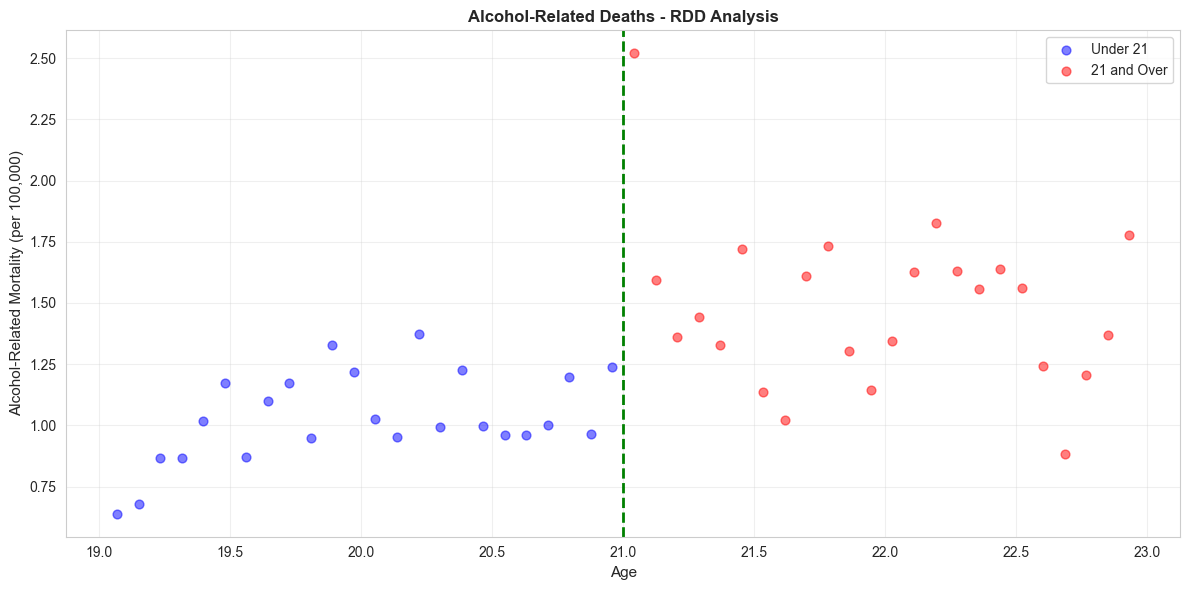

In [30]:
# ============================================================
# Drinking Data RDD Visualization
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

mask_below = df_drinking['agecell'] < cutoff_age
mask_above = df_drinking['agecell'] >= cutoff_age

ax.scatter(df_drinking[mask_below]['agecell'], df_drinking[mask_below]['alcohol'],
            alpha=0.5, s=40, color='blue', label='Under 21')
ax.scatter(df_drinking[mask_above]['agecell'], df_drinking[mask_above]['alcohol'],
            alpha=0.5, s=40, color='red', label='21 and Over')

ax.axvline(cutoff_age, color='green', linestyle='--', linewidth=2)
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Alcohol-Related Mortality (per 100,000)', fontsize=11)
ax.set_title('Alcohol-Related Deaths - RDD Analysis', fontsize=12, weight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. McCrary 밀도 검정 (조작 탐지)

RDD 가정의 핵심: "배정변수 X가 임계값에서 조작되지 않는다"

**McCrary (2008) 밀도 검정**: 배정변수의 확률밀도함수가 임계값에서 불연속인지 검정

In [31]:
# ============================================================
# McCrary 밀도 검정
# ============================================================

def mccrary_density_test(X, cutoff, bandwidth=None, num_bins=50):
    """
    McCrary 밀도 검정을 간단히 구현한다.
    """
    if bandwidth is not None:
        mask = np.abs(X - cutoff) <= bandwidth
        X_test = X[mask]
    else:
        X_test = X
    
    X_left = X_test[X_test < cutoff]
    X_right = X_test[X_test >= cutoff]
    
    hist_left, bins_left = np.histogram(X_left, bins=num_bins, density=True)
    hist_right, bins_right = np.histogram(X_right, bins=num_bins, density=True)
    
    density_left = hist_left[-1]
    density_right = hist_right[0]
    
    log_density_ratio = np.log(density_right / density_left)
    
    n_left, n_right = len(X_left), len(X_right)
    se = np.sqrt(1/n_left + 1/n_right)
    z_stat = log_density_ratio / se
    p_value = 2 * stats.norm.sf(np.abs(z_stat))
    
    return {
        'density_left': density_left,
        'density_right': density_right,
        'log_ratio': log_density_ratio,
        'z_stat': z_stat,
        'p_value': p_value,
        'n_left': n_left,
        'n_right': n_right
    }

result_mccrary = mccrary_density_test(X, cutoff, bandwidth=20)

print("="*60)
print("McCrary 밀도 검정")
print("="*60)
print(f"z-통계량: {result_mccrary['z_stat']:.4f}")
print(f"p-값: {result_mccrary['p_value']:.4f}")


McCrary 밀도 검정
z-통계량: 1.6316
p-값: 0.1028


In [32]:
# ============================================================
# CAIS 패턴과의 비교
# ============================================================

comparison = pd.DataFrame({
    '우리 구현': ['above_cutoff', 'X_centered', 'X_X_above', 'HC1 강건한 SE'],
    'CAIS 라이브러리': ['TREATED', 'running_centered', 'running_x_above', 'HC1 강건한 SE'],
    '의미': ['처치 효과', '임계값 아래 기울기', '기울기 변화', '통계 추론']
})

print("="*70)
print("우리 구현 vs CAIS 라이브러리 비교")
print("="*70)
print(comparison.to_string(index=False))


우리 구현 vs CAIS 라이브러리 비교
       우리 구현       CAIS 라이브러리         의미
above_cutoff          TREATED      처치 효과
  X_centered running_centered 임계값 아래 기울기
   X_X_above  running_x_above     기울기 변화
  HC1 강건한 SE       HC1 강건한 SE      통계 추론
